<a href="https://colab.research.google.com/github/berraibis/Samsung-AI-Homework1/blob/main/%C3%A7apar_ibi%C5%9F_assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

            Timestamp Temperature   Humidity SquareFootage Occupancy  \
0 2022-01-01 00:00:00   25.139433  43.431581   1565.693999         5   
1 2022-01-01 01:00:00   27.731651  54.225919   1411.064918         1   
2 2022-01-01 02:00:00   28.704277  58.907658   1755.715009         2   
3 2022-01-01 03:00:00   20.080469  50.371637   1452.316318         1   
4 2022-01-01 04:00:00   23.097359  51.401421   1094.130359         9   

  HVACUsage LightingUsage RenewableEnergy  DayOfWeek Holiday EnergyConsumption  
0        On           Off        2.774699     Monday      No         75.364373  
1        On            On       21.831384   Saturday      No         83.401855  
2       Off           Off        6.764672     Sunday      No         78.270888  
3       Off            On        8.623447  Wednesday      No          56.51985  
4        On           Off        3.071969     Friday      No         70.811732  
     Timestamp          Temperature             Humidity        SquareFootage  \


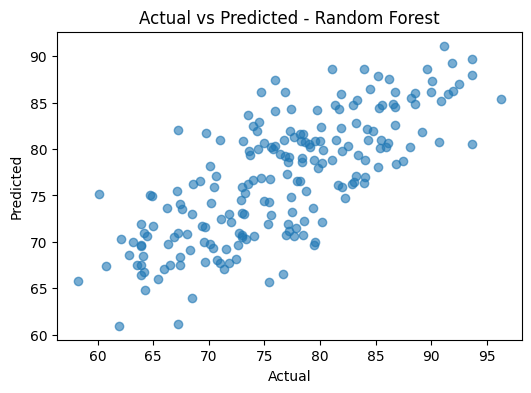

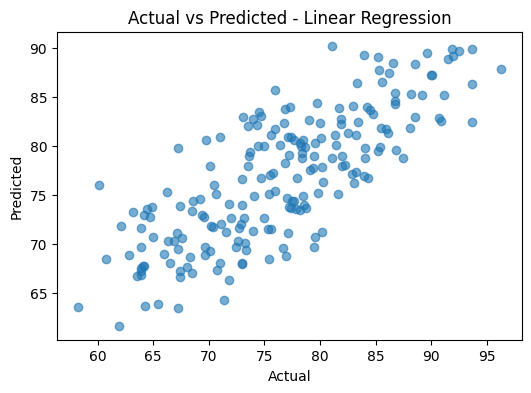

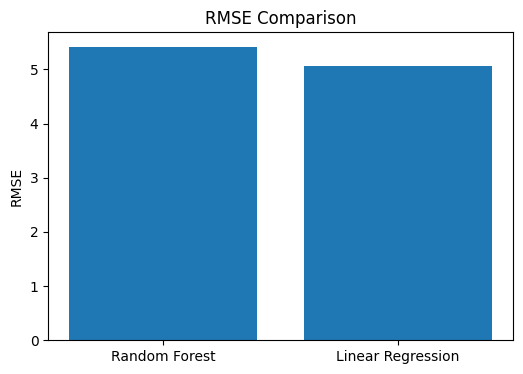

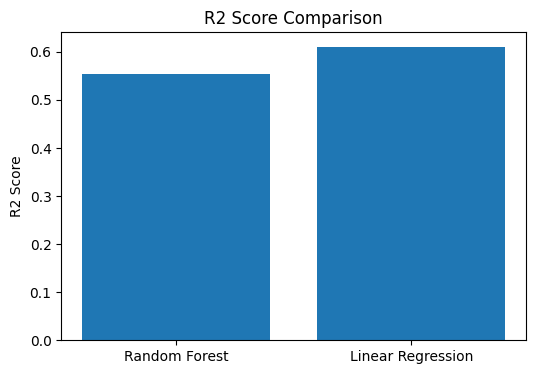


Top Important Features
                Feature  Importance
0           Temperature    0.572589
1              Humidity    0.092238
4       RenewableEnergy    0.076632
2         SquareFootage    0.075757
5          HVACUsage_On    0.062940
3             Occupancy    0.062383
6      LightingUsage_On    0.012012
7      DayOfWeek_Monday    0.008616
13          Holiday_Yes    0.008146
12  DayOfWeek_Wednesday    0.006537


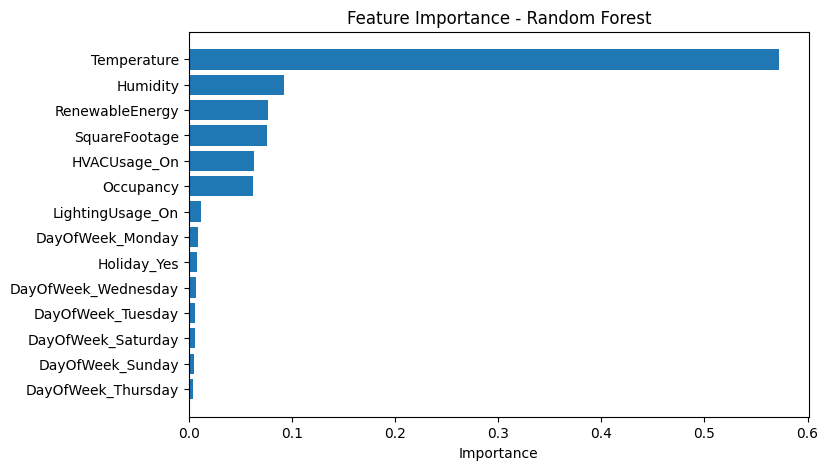

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load dataset
df = pd.read_excel("dataset.xlsx")

print(df.head())
print(df.tail())
print(df.info())

# 2. Remove possible summary / broken rows
# Numeric columns should be converted to numeric values
numeric_cols = [
    "Temperature",
    "Humidity",
    "SquareFootage",
    "Occupancy",
    "RenewableEnergy",
    "EnergyConsumption"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop rows that became NaN after conversion
df = df.dropna(subset=numeric_cols)

# 3. Define target and features
y = df["EnergyConsumption"]

X = df.drop(["EnergyConsumption", "Timestamp"], axis=1)

# 4. Convert categorical variables into numeric
X = pd.get_dummies(
    X,
    columns=["HVACUsage", "LightingUsage", "DayOfWeek", "Holiday"],
    drop_first=True
)

# Extra safety: make sure all remaining values are numeric
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna()

# Keep y aligned with cleaned X
y = y.loc[X.index]

# 5. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6. Scale data for Linear Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 7. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 8. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# 9. Evaluation
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

rf_results = evaluate(y_test, y_pred_rf)
lr_results = evaluate(y_test, y_pred_lr)

print("\nRandom Forest (MAE, RMSE, R2):", rf_results)
print("Linear Regression (MAE, RMSE, R2):", lr_results)

# 10. Comparison table
results = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression"],
    "MAE": [rf_results[0], lr_results[0]],
    "RMSE": [rf_results[1], lr_results[1]],
    "R2 Score": [rf_results[2], lr_results[2]]
})

print("\nModel Comparison")
print(results)

# 11. Visualizations
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted - Random Forest")
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_lr, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results["Model"], results["R2 Score"])
plt.title("R2 Score Comparison")
plt.ylabel("R2 Score")
plt.show()

# 12. Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features")
print(importance.head(10))

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()